`Loading Datasets`

In [2]:
import kagglehub, pandas as pd

path = kagglehub.dataset_download("harunshimanto/epileptic-seizure-recognition")
print(path)

df_k = pd.read_csv(path + "/Epileptic Seizure Recognition.csv")
df_k.head()

Using Colab cache for faster access to the 'epileptic-seizure-recognition' dataset.
/kaggle/input/epileptic-seizure-recognition


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [3]:
import pandas as pd

df_uci = pd.read_csv("/content/BEED_Data.csv")

df_uci.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [4]:
import zipfile, os, numpy as np

for name in ['S', 'Z', 'O', 'N', 'F']:
    with zipfile.ZipFile(f"/content/{name}.zip", 'r') as z:
        z.extractall(f"bonn_{name}")

In [5]:
def extract_features(folder):
    signals = []
    for file in sorted(os.listdir(folder)):
        if file.lower().endswith(".txt"):
            signal = np.loadtxt(os.path.join(folder, file))
            signals.append(signal)
    return np.array([[np.mean(s), np.std(s), np.var(s),
                      np.min(s), np.max(s), np.median(s),
                      np.sum(s**2)] for s in signals])

In [6]:
X_bonn = np.vstack([extract_features(f"bonn_{n}") for n in ['S','Z','O','N','F']])
y_bonn = np.concatenate([np.ones(100), np.zeros(400)])
print("Bonn shape:", X_bonn.shape, y_bonn.shape)


Bonn shape: (500, 7) (500,)


Size

Class imbalance

Feature characteristics (time-series vs extracted features)

In [7]:
# Dataset 1 (Kaggle) — binarize y
df_k['label'] = (df_k['y'] == 1).astype(int)

print("=== Dataset 1: Kaggle Epileptic Seizure ===")
print("Shape:", df_k.shape)
print("Class distribution:\n", df_k['label'].value_counts())
print("Imbalance ratio:", round(df_k['label'].value_counts()[0] / df_k['label'].value_counts()[1], 2))

# Dataset 2 (BEED) — binarize y
df_uci['label'] = (df_uci['y'] != 0).astype(int)

print("\n=== Dataset 2: BEED ===")
print("Shape:", df_uci.shape)
print("Class distribution:\n", df_uci['label'].value_counts())
print("Imbalance ratio:", round(df_uci['label'].value_counts()[1] / df_uci['label'].value_counts()[0], 2))

# Dataset 3 (Bonn) — already binary
print("\n=== Dataset 3: Bonn ===")
print("Shape:", X_bonn.shape)
unique, counts = np.unique(y_bonn, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))
print("Imbalance ratio:", round(counts[0]/counts[1], 2))

=== Dataset 1: Kaggle Epileptic Seizure ===
Shape: (11500, 181)
Class distribution:
 label
0    9200
1    2300
Name: count, dtype: int64
Imbalance ratio: 4.0

=== Dataset 2: BEED ===
Shape: (8000, 18)
Class distribution:
 label
1    6000
0    2000
Name: count, dtype: int64
Imbalance ratio: 3.0

=== Dataset 3: Bonn ===
Shape: (500, 7)
Class distribution: {np.float64(0.0): np.int64(400), np.float64(1.0): np.int64(100)}
Imbalance ratio: 4.0


**Preprocessing Pipeline**

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Dataset 1 - Kaggle UCI
X1 = df_k.drop(columns=['Unnamed', 'y', 'label']).values
y1 = df_k['label'].values

# Dataset 2 - BEED
X2 = df_uci.drop(columns=['y', 'label']).values
y2 = df_uci['label'].values

# Dataset 3 - Bonn (already numpy arrays)
X3 = X_bonn
y3 = y_bonn

# Train/test split for all 3
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

print("Dataset 1 train/test:", X1_train.shape, X1_test.shape)
print("Dataset 2 train/test:", X2_train.shape, X2_test.shape)
print("Dataset 3 train/test:", X3_train.shape, X3_test.shape)

Dataset 1 train/test: (9200, 178) (2300, 178)
Dataset 2 train/test: (6400, 16) (1600, 16)
Dataset 3 train/test: (400, 7) (100, 7)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures

# ── Pipeline A: Normalization → Noise Removal → Feature Selection ──
pipeline_A = Pipeline([
    ('scaler',    StandardScaler()),
    ('noise',     VarianceThreshold(threshold=0.01)),  # remove near-zero variance
    ('selector',  SelectKBest(f_classif, k=20))        # keep top 20 features
])

# ── Pipeline B: Feature Extraction → Scaling → PCA ──
pipeline_B = Pipeline([
    ('extractor', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler',    MinMaxScaler()),
    ('pca',       PCA(n_components=20))                # reduce to 20 components
])

print("Pipeline A steps:", [s[0] for s in pipeline_A.steps])
print("Pipeline B steps:", [s[0] for s in pipeline_B.steps])

Pipeline A steps: ['scaler', 'noise', 'selector']
Pipeline B steps: ['extractor', 'scaler', 'pca']


In [10]:
datasets = {
    'Dataset1_UCI': (X1_train, X1_test, y1_train, y1_test),
    'Dataset2_BEED': (X2_train, X2_test, y2_train, y2_test),
    'Dataset3_Bonn': (X3_train, X3_test, y3_train, y3_test),
}

transformed = {}  # store results for use in later steps

for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    print(f"\n=== {name} ===")

    # Pipeline A
    try:
        Xa_train = pipeline_A.fit_transform(X_tr, y_tr)
        Xa_test  = pipeline_A.transform(X_te)
        print(f"  Pipeline A → train: {Xa_train.shape}, test: {Xa_test.shape}")
    except Exception as e:
        print(f"  Pipeline A failed: {e}")
        Xa_train, Xa_test = None, None

    # Pipeline B
    try:
        Xb_train = pipeline_B.fit_transform(X_tr, y_tr)
        Xb_test  = pipeline_B.transform(X_te)
        print(f"  Pipeline B → train: {Xb_train.shape}, test: {Xb_test.shape}")
    except Exception as e:
        print(f"  Pipeline B failed: {e}")
        Xb_train, Xb_test = None, None

    transformed[name] = {
        'A': (Xa_train, Xa_test, y_tr, y_te),
        'B': (Xb_train, Xb_test, y_tr, y_te),
    }


=== Dataset1_UCI ===
  Pipeline A → train: (9200, 20), test: (2300, 20)
  Pipeline B → train: (9200, 20), test: (2300, 20)

=== Dataset2_BEED ===
  Pipeline A → train: (6400, 16), test: (1600, 16)
  Pipeline B → train: (6400, 20), test: (1600, 20)

=== Dataset3_Bonn ===
  Pipeline A → train: (400, 7), test: (100, 7)
  Pipeline B → train: (400, 20), test: (100, 20)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=16. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=7. All the features will be returned.
  warnings.warn(


**Baseline Model: Logistic Regression**

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
import pandas as pd

def evaluate(model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    pr_auc  = average_precision_score(y_test, y_prob)
    return acc, f1, pr_auc

results = []

for name, pipes in transformed.items():
    for pipe_name in ['A', 'B']:
        Xtr, Xte, ytr, yte = pipes[pipe_name]

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(Xtr, ytr)

        acc, f1, pr_auc = evaluate(model, Xte, yte)

        results.append({
            'Dataset':   name,
            'Pipeline':  pipe_name,
            'Accuracy':  round(acc, 4),
            'F1-Score':  round(f1, 4),
            'PR-AUC':    round(pr_auc, 4)
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

      Dataset Pipeline  Accuracy  F1-Score  PR-AUC
 Dataset1_UCI        A    0.8052    0.0508  0.4171
 Dataset1_UCI        B    0.9417    0.8329  0.9575
Dataset2_BEED        A    0.8063    0.8850  0.7618
Dataset2_BEED        B    0.9444    0.9642  0.9982
Dataset3_Bonn        A    0.9400    0.8500  0.9069
Dataset3_Bonn        B    0.9100    0.7568  0.8942


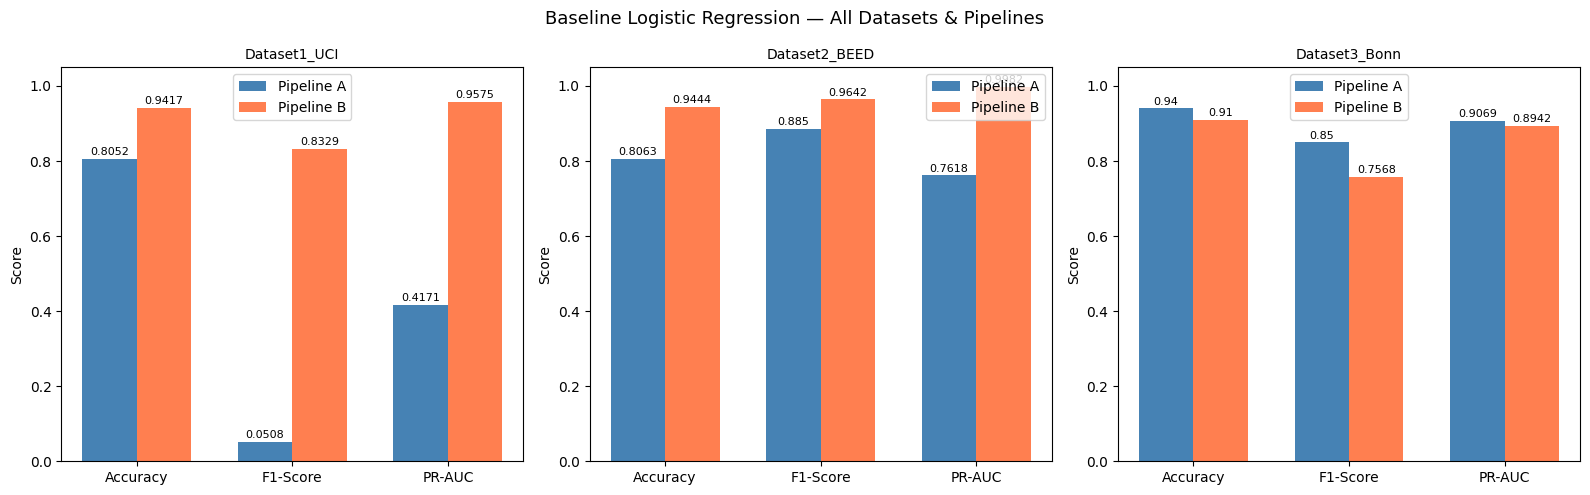

Plot saved as baseline_results.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

metrics   = ['Accuracy', 'F1-Score', 'PR-AUC']
datasets  = df_results['Dataset'].unique()
x         = np.arange(len(metrics))
width     = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Logistic Regression — All Datasets & Pipelines', fontsize=13)

for ax, dataset in zip(axes, datasets):
    sub = df_results[df_results['Dataset'] == dataset]
    pA  = sub[sub['Pipeline'] == 'A'][metrics].values.flatten()
    pB  = sub[sub['Pipeline'] == 'B'][metrics].values.flatten()

    ax.bar(x - width/2, pA, width, label='Pipeline A', color='steelblue')
    ax.bar(x + width/2, pB, width, label='Pipeline B', color='coral')
    ax.set_title(dataset, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_ylabel('Score')

    # annotate values on bars
    for i, v in enumerate(pA):
        ax.text(i - width/2, v + 0.01, str(v), ha='center', fontsize=8)
    for i, v in enumerate(pB):
        ax.text(i + width/2, v + 0.01, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as baseline_results.png")

**Overfitting & Underfitting**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

# Use Dataset 1 (UCI) — largest dataset, best for demonstrating curves
X_demo = df_k.drop(columns=['Unnamed', 'y', 'label']).values
y_demo = df_k['label'].values

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42, stratify=y_demo
)

# ── Underfitting setup: very strong regularization + only 2 features ──
X_under_tr = X_tr[:, :2]   # only first 2 features
X_under_te = X_te[:, :2]

# ── Overfitting setup: no regularization + all 178 features ──
X_over_tr = X_tr            # all features
X_over_te = X_te

print("Underfitting — feature shape:", X_under_tr.shape)
print("Overfitting  — feature shape:", X_over_tr.shape)

Underfitting — feature shape: (9200, 2)
Overfitting  — feature shape: (9200, 178)


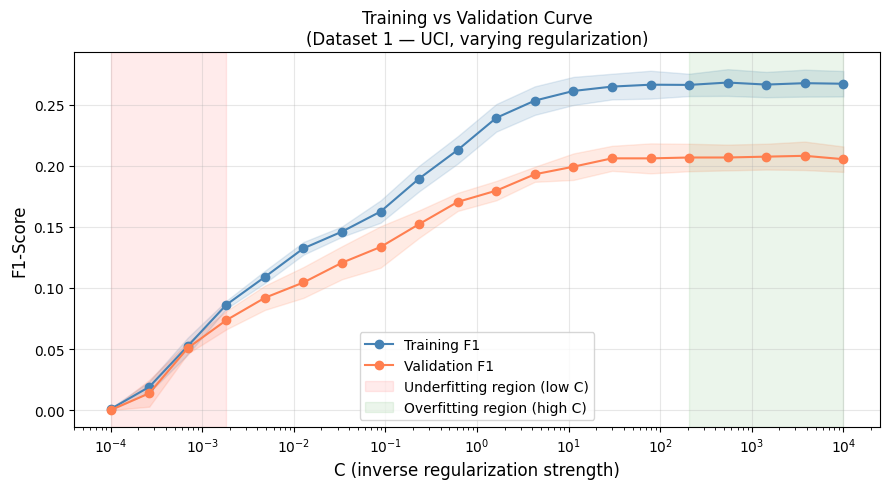

Saved: validation_curve.png


In [14]:
from sklearn.model_selection import validation_curve

C_values = np.logspace(-4, 4, 20)  # from 0.0001 to 10000

# Scale first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_demo)

train_scores, val_scores = validation_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_scaled, y_demo,
    param_name='C',
    param_range=C_values,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.semilogx(C_values, train_mean, 'o-', color='steelblue', label='Training F1')
plt.semilogx(C_values, val_mean,   'o-', color='coral',     label='Validation F1')
plt.fill_between(C_values, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(C_values, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='coral')

plt.axvspan(C_values[0],  C_values[3],  alpha=0.08, color='red',   label='Underfitting region (low C)')
plt.axvspan(C_values[15], C_values[-1], alpha=0.08, color='green', label='Overfitting region (high C)')

plt.xlabel('C (inverse regularization strength)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Training vs Validation Curve\n(Dataset 1 — UCI, varying regularization)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: validation_curve.png")

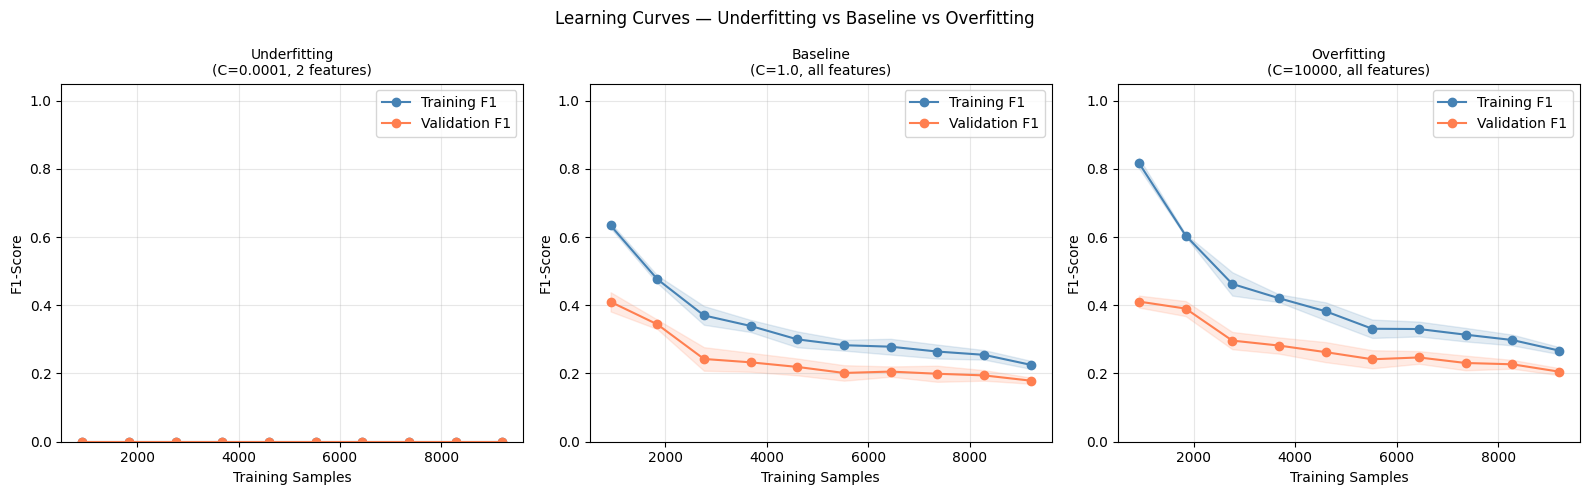

Saved: learning_curves.png


In [15]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Learning Curves — Underfitting vs Baseline vs Overfitting', fontsize=12)

scenarios = [
    ('Underfitting\n(C=0.0001, 2 features)', X_scaled[:, :2],  0.0001),
    ('Baseline\n(C=1.0, all features)',       X_scaled,          1.0),
    ('Overfitting\n(C=10000, all features)',  X_scaled,          10000),
]

for ax, (title, X_s, C) in zip(axes, scenarios):
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)

    train_sizes, train_sc, val_sc = learning_curve(
        model, X_s, y_demo,
        cv=5,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    tr_mean = train_sc.mean(axis=1)
    tr_std  = train_sc.std(axis=1)
    v_mean  = val_sc.mean(axis=1)
    v_std   = val_sc.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Training F1')
    ax.plot(train_sizes, v_mean,  'o-', color='coral',     label='Validation F1')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes, v_mean  - v_std,  v_mean  + v_std,  alpha=0.15, color='coral')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

In [16]:
from sklearn.metrics import accuracy_score, f1_score, average_precision_score

scenarios_eval = [
    ('Underfitting', LogisticRegression(C=0.0001, max_iter=1000, random_state=42), X_under_tr, X_under_te),
    ('Baseline',     LogisticRegression(C=1.0,    max_iter=1000, random_state=42), X_over_tr,  X_over_te),
    ('Overfitting',  LogisticRegression(C=10000,  max_iter=1000, random_state=42), X_over_tr,  X_over_te),
]

scaler2 = StandardScaler()

print(f"{'Scenario':<15} {'Train Acc':>10} {'Val Acc':>10} {'Train F1':>10} {'Val F1':>10} {'PR-AUC':>10}")
print("-" * 65)

for label, model, Xtr_s, Xte_s in scenarios_eval:
    Xtr_sc = scaler2.fit_transform(Xtr_s)
    Xte_sc = scaler2.transform(Xte_s)

    model.fit(Xtr_sc, y_tr)

    tr_f1  = f1_score(y_tr, model.predict(Xtr_sc))
    va_f1  = f1_score(y_te, model.predict(Xte_sc))
    tr_acc = accuracy_score(y_tr, model.predict(Xtr_sc))
    va_acc = accuracy_score(y_te, model.predict(Xte_sc))
    prauc  = average_precision_score(y_te, model.predict_proba(Xte_sc)[:, 1])

    print(f"{label:<15} {tr_acc:>10.4f} {va_acc:>10.4f} {tr_f1:>10.4f} {va_f1:>10.4f} {prauc:>10.4f}")

Scenario         Train Acc    Val Acc   Train F1     Val F1     PR-AUC
-----------------------------------------------------------------
Underfitting        0.8000     0.8000     0.0000     0.0000     0.4713
Baseline            0.8282     0.8157     0.2482     0.1520     0.4312
Overfitting         0.8309     0.8196     0.2722     0.1942     0.4026


**Regularization Study**

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
import numpy as np
import pandas as pd

datasets_raw = {
    'UCI':  (X1_train, X1_test, y1_train, y1_test),
    'BEED': (X2_train, X2_test, y2_train, y2_test),
    'Bonn': (X3_train, X3_test, y3_train, y3_test),
}

regularizers = {
    'L1':          dict(penalty='l1', solver='liblinear', C=1.0, max_iter=1000),
    'L2':          dict(penalty='l2', solver='lbfgs',     C=1.0, max_iter=1000),
    'Elastic Net': dict(penalty='elasticnet', solver='saga',
                        C=1.0, l1_ratio=0.5, max_iter=2000),
}

records = []
models_store = {}

for ds_name, (Xtr, Xte, ytr, yte) in datasets_raw.items():
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)

    for reg_name, params in regularizers.items():
        model = LogisticRegression(random_state=42, **params)  # ← fix here
        model.fit(Xtr_sc, ytr)

        y_pred = model.predict(Xte_sc)
        y_prob = model.predict_proba(Xte_sc)[:, 1]

        acc   = accuracy_score(yte, y_pred)
        f1    = f1_score(yte, y_pred, zero_division=0)
        prauc = average_precision_score(yte, y_prob)

        coef     = model.coef_[0]
        n_zero   = np.sum(np.abs(coef) < 1e-6)
        sparsity = round(n_zero / len(coef) * 100, 1)

        records.append({
            'Dataset':     ds_name,
            'Regularizer': reg_name,
            'Accuracy':    round(acc,   4),
            'F1-Score':    round(f1,    4),
            'PR-AUC':      round(prauc, 4),
            'Zero Coefs':  n_zero,
            'Sparsity %':  sparsity,
        })
        models_store[(ds_name, reg_name)] = (model, coef)

df_reg = pd.DataFrame(records)
print(df_reg.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Dataset Regularizer  Accuracy  F1-Score  PR-AUC  Zero Coefs  Sparsity %
    UCI          L1    0.8152    0.1483  0.4323          48        27.0
    UCI          L2    0.8157    0.1520  0.4312           0         0.0
    UCI Elastic Net    0.8148    0.1446  0.4353          26        14.6
   BEED          L1    0.8075    0.8859  0.7608           0         0.0
   BEED          L2    0.8063    0.8850  0.7618           0         0.0
   BEED Elastic Net    0.8075    0.8859  0.7613           0         0.0
   Bonn          L1    0.9500    0.8780  0.9137           2        28.6
   Bonn          L2    0.9400    0.8500  0.9069           0         0.0
   Bonn Elastic Net    0.9400    0.8500  0.9069           1        14.3


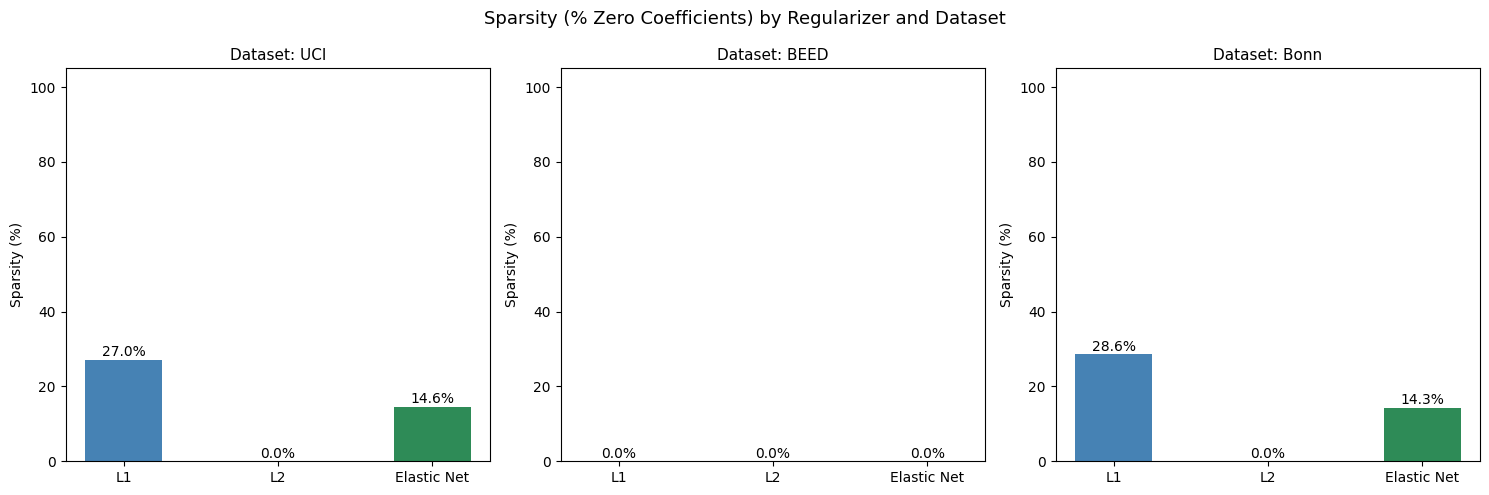

Saved: sparsity.png


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sparsity (% Zero Coefficients) by Regularizer and Dataset', fontsize=13)

colors = {'L1': 'steelblue', 'L2': 'coral', 'Elastic Net': 'seagreen'}

for ax, ds_name in zip(axes, ['UCI', 'BEED', 'Bonn']):
    sub = df_reg[df_reg['Dataset'] == ds_name]
    bars = ax.bar(sub['Regularizer'], sub['Sparsity %'],
                  color=[colors[r] for r in sub['Regularizer']], width=0.5)
    ax.set_title(f'Dataset: {ds_name}', fontsize=11)
    ax.set_ylabel('Sparsity (%)')
    ax.set_ylim(0, 105)
    for bar, val in zip(bars, sub['Sparsity %']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sparsity.png")

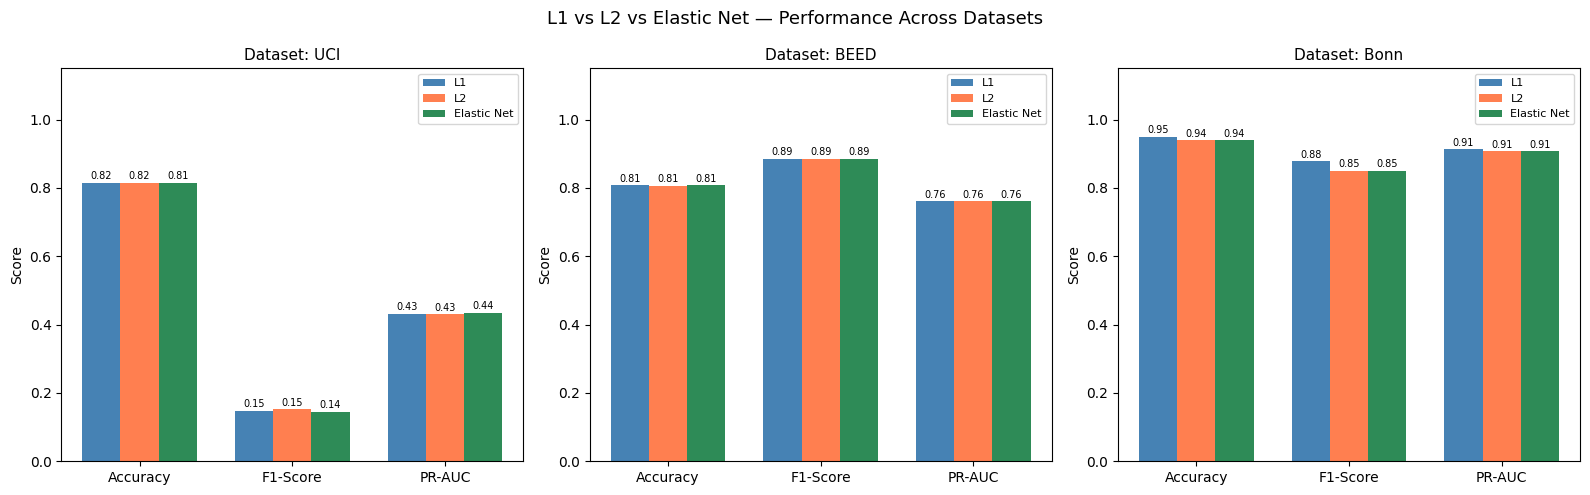

Saved: regularization_metrics.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('L1 vs L2 vs Elastic Net — Performance Across Datasets', fontsize=13)

metrics = ['Accuracy', 'F1-Score', 'PR-AUC']
x = np.arange(len(metrics))
width = 0.25

for ax, ds_name in zip(axes, ['UCI', 'BEED', 'Bonn']):
    sub = df_reg[df_reg['Dataset'] == ds_name]
    for i, (reg_name, color) in enumerate(colors.items()):
        row = sub[sub['Regularizer'] == reg_name][metrics].values.flatten()
        bars = ax.bar(x + (i - 1) * width, row, width,
                      label=reg_name, color=color)
        for bar, val in zip(bars, row):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01, f'{val:.2f}',
                    ha='center', fontsize=7)

    ax.set_title(f'Dataset: {ds_name}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('regularization_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regularization_metrics.png")

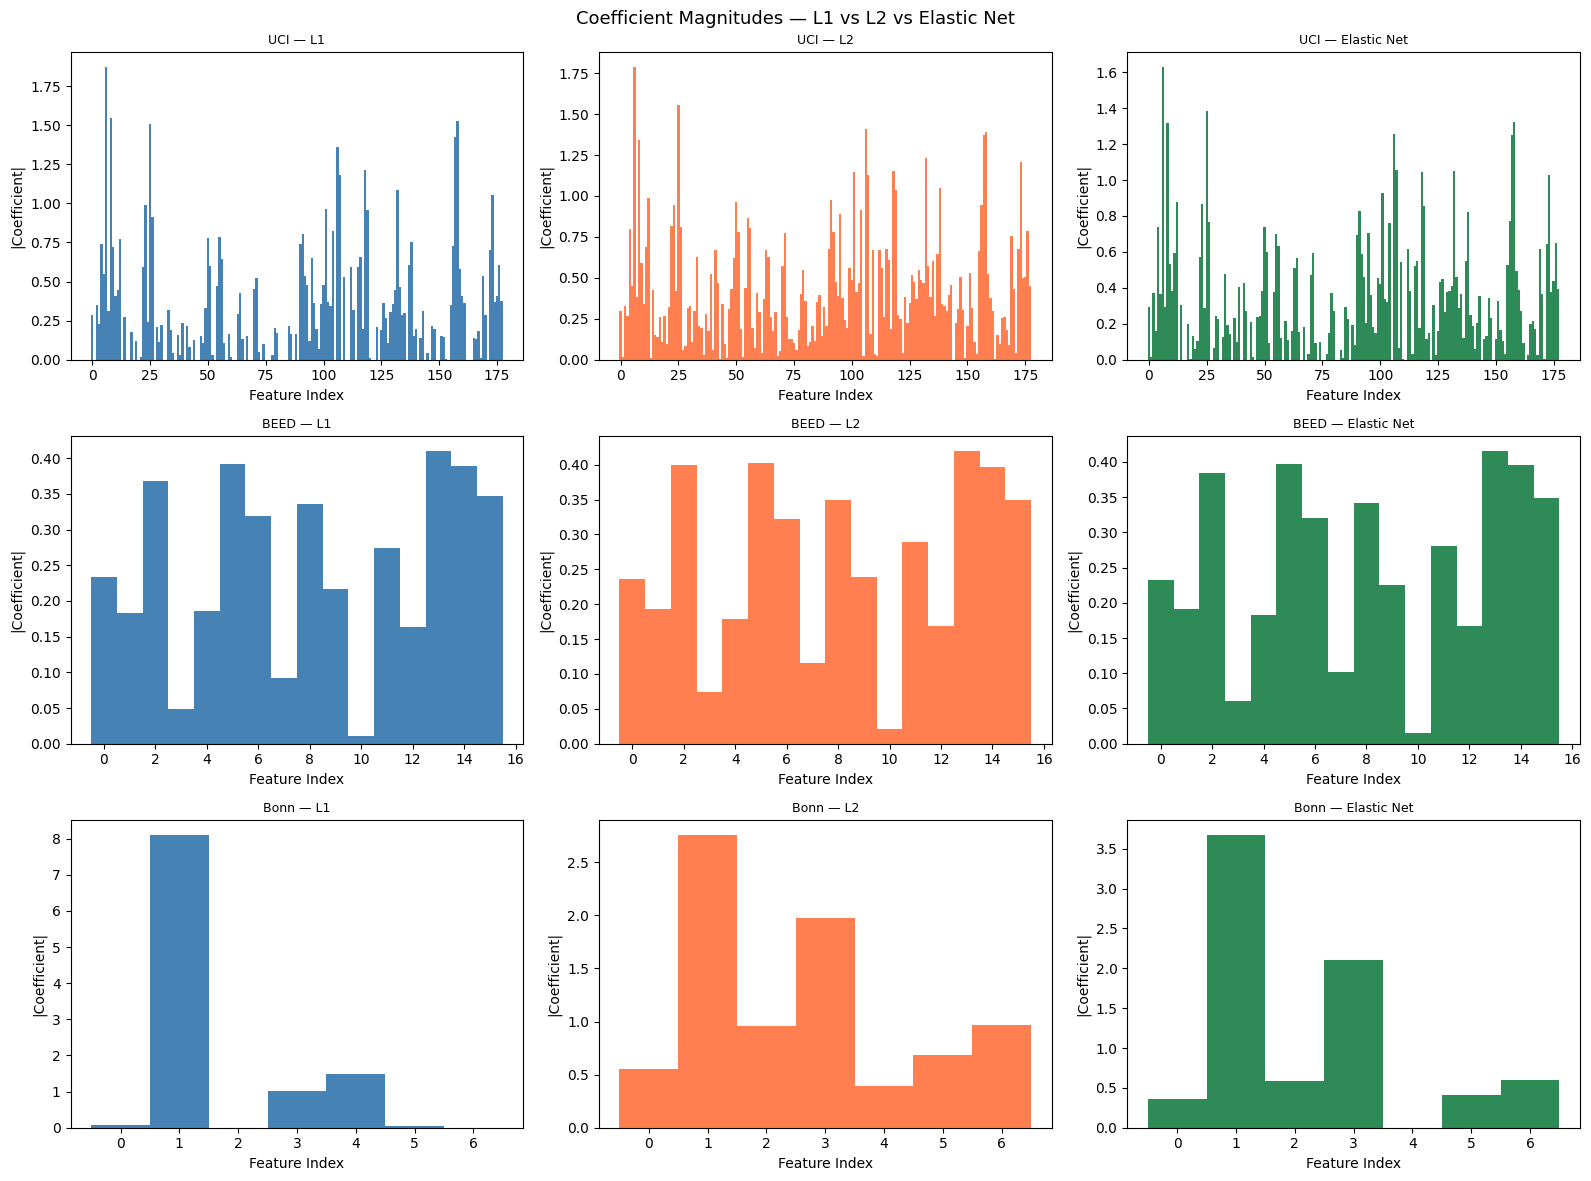

Saved: coef_magnitudes.png


In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Coefficient Magnitudes — L1 vs L2 vs Elastic Net', fontsize=13)

for row_i, ds_name in enumerate(['UCI', 'BEED', 'Bonn']):
    for col_i, reg_name in enumerate(['L1', 'L2', 'Elastic Net']):
        ax = axes[row_i][col_i]
        _, coef = models_store[(ds_name, reg_name)]
        ax.bar(range(len(coef)), np.abs(coef),
               color=list(colors.values())[col_i], width=1.0)
        ax.set_title(f'{ds_name} — {reg_name}', fontsize=9)
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('|Coefficient|')

plt.tight_layout()
plt.savefig('coef_magnitudes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: coef_magnitudes.png")

**Handling Class Imbalance**

In [22]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
datasets_raw = {
    'UCI':  (X1_train, X1_test, y1_train, y1_test),
    'BEED': (X2_train, X2_test, y2_train, y2_test),
    'Bonn': (X3_train, X3_test, y3_train, y3_test),
}

records = []
pr_curves = {}  # store for plotting

for ds_name, (Xtr, Xte, ytr, yte) in datasets_raw.items():
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)

    techniques = {
        'No Handling':     (Xtr_sc, ytr),
        'SMOTE':           SMOTE(random_state=42).fit_resample(Xtr_sc, ytr),
        'Undersampling':   RandomUnderSampler(random_state=42).fit_resample(Xtr_sc, ytr),
        'Class Weighting': (Xtr_sc, ytr),  # handled via model param
    }

    pr_curves[ds_name] = {}

    for tech_name, (X_res, y_res) in techniques.items():
        if tech_name == 'Class Weighting':
            model = LogisticRegression(C=1.0, max_iter=1000,
                                       class_weight='balanced',
                                       random_state=42)
        else:
            model = LogisticRegression(C=1.0, max_iter=1000,
                                       random_state=42)

        model.fit(X_res, y_res)
        y_pred = model.predict(Xte_sc)
        y_prob = model.predict_proba(Xte_sc)[:, 1]

        prec  = precision_score(yte, y_pred, zero_division=0)
        rec   = recall_score(yte, y_pred, zero_division=0)
        f1    = f1_score(yte, y_pred, zero_division=0)
        prauc = average_precision_score(yte, y_prob)

        # store PR curve points
        p_curve, r_curve, _ = precision_recall_curve(yte, y_prob)
        pr_curves[ds_name][tech_name] = (p_curve, r_curve, prauc)

        # class counts after resampling
        unique, counts = np.unique(y_res, return_counts=True)
        ratio = f'{counts[0]}:{counts[1]}'

        records.append({
            'Dataset':    ds_name,
            'Technique':  tech_name,
            'Resampled':  ratio,
            'Precision':  round(prec,  4),
            'Recall':     round(rec,   4),
            'F1-Score':   round(f1,    4),
            'PR-AUC':     round(prauc, 4),
        })

df_imb = pd.DataFrame(records)
print(df_imb.to_string(index=False))

Dataset       Technique Resampled  Precision  Recall  F1-Score  PR-AUC
    UCI     No Handling 7360:1840     0.9500  0.0826    0.1520  0.4312
    UCI           SMOTE 7360:7360     0.3146  0.4370    0.3658  0.4135
    UCI   Undersampling 1840:1840     0.2873  0.4022    0.3351  0.3924
    UCI Class Weighting 7360:1840     0.3137  0.3935    0.3491  0.3979
   BEED     No Handling 1600:4800     0.7975  0.9942    0.8850  0.7618
   BEED           SMOTE 4800:4800     0.8213  0.6242    0.7093  0.8168
   BEED   Undersampling 1600:1600     0.8157  0.6308    0.7115  0.8192
   BEED Class Weighting 1600:4800     0.8207  0.6408    0.7197  0.8120
   Bonn     No Handling    320:80     0.8500  0.8500    0.8500  0.9069
   Bonn           SMOTE   320:320     0.8261  0.9500    0.8837  0.9046
   Bonn   Undersampling     80:80     0.8261  0.9500    0.8837  0.8995
   Bonn Class Weighting    320:80     0.8261  0.9500    0.8837  0.8986


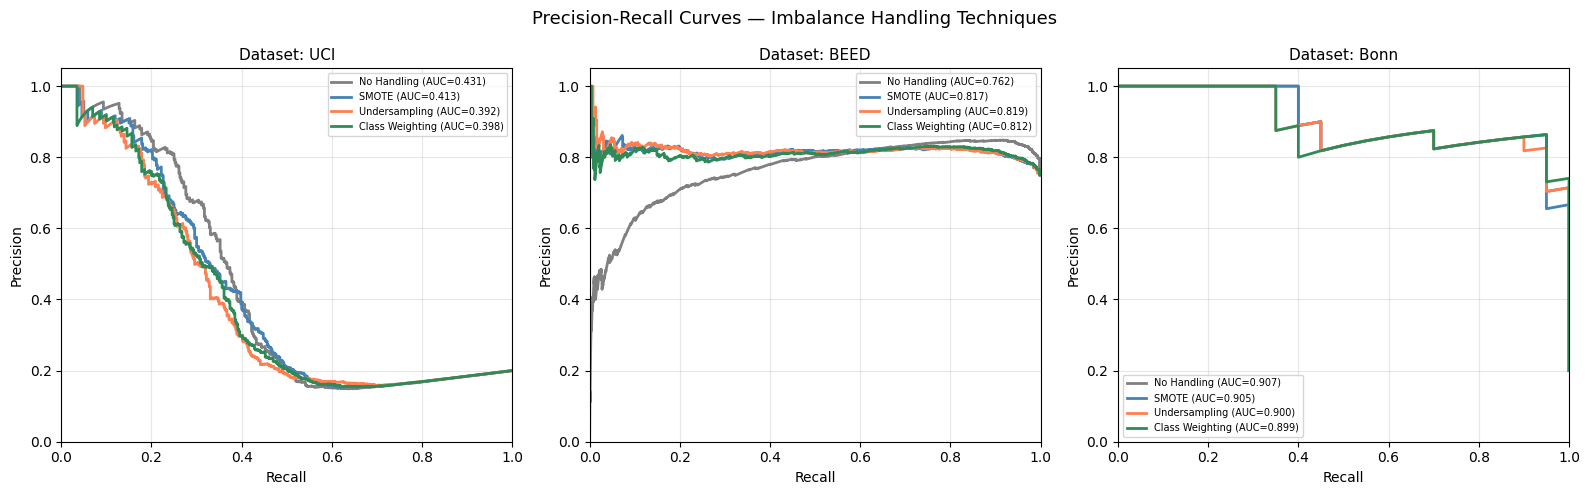

Saved: pr_curves.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Precision-Recall Curves — Imbalance Handling Techniques', fontsize=13)

colors = {
    'No Handling':     'grey',
    'SMOTE':           'steelblue',
    'Undersampling':   'coral',
    'Class Weighting': 'seagreen',
}

for ax, ds_name in zip(axes, ['UCI', 'BEED', 'Bonn']):
    for tech_name, (p_curve, r_curve, prauc) in pr_curves[ds_name].items():
        ax.plot(r_curve, p_curve,
                color=colors[tech_name],
                label=f'{tech_name} (AUC={prauc:.3f})',
                linewidth=2)
    ax.set_title(f'Dataset: {ds_name}', fontsize=11)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pr_curves.png")

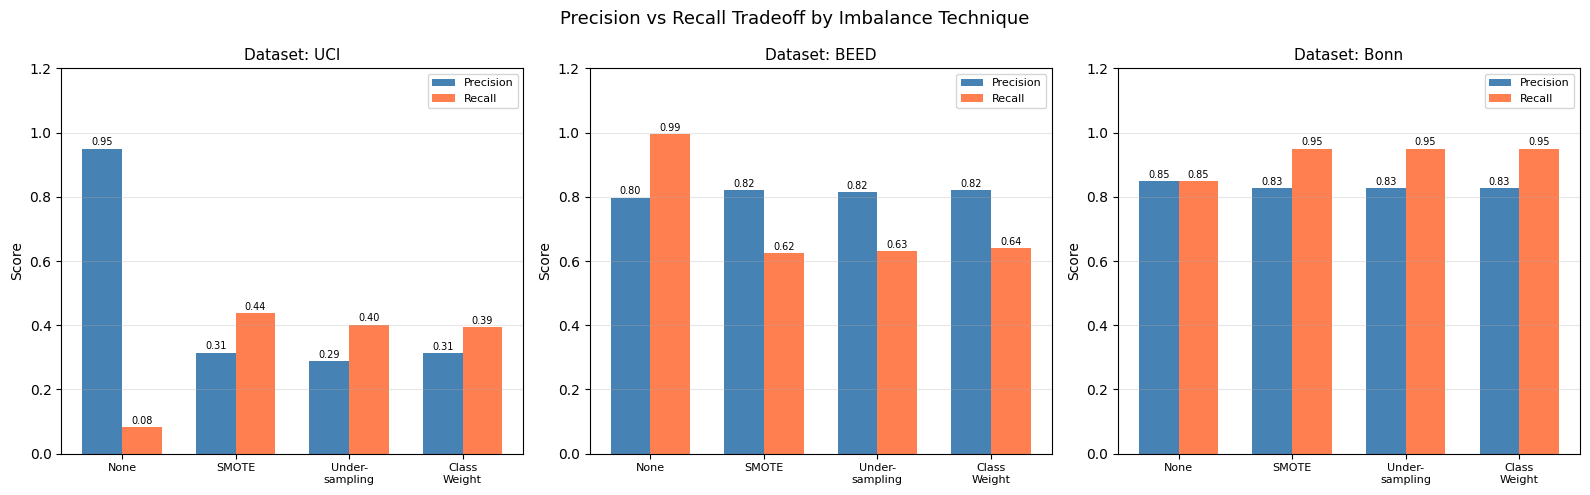

Saved: precision_recall_tradeoff.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Precision vs Recall Tradeoff by Imbalance Technique', fontsize=13)

techniques = ['No Handling', 'SMOTE', 'Undersampling', 'Class Weighting']
x = np.arange(len(techniques))
width = 0.35

for ax, ds_name in zip(axes, ['UCI', 'BEED', 'Bonn']):
    sub = df_imb[df_imb['Dataset'] == ds_name]
    prec_vals = sub['Precision'].values
    rec_vals  = sub['Recall'].values

    b1 = ax.bar(x - width/2, prec_vals, width, label='Precision', color='steelblue')
    b2 = ax.bar(x + width/2, rec_vals,  width, label='Recall',    color='coral')

    for bar, v in zip(b1, prec_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01, f'{v:.2f}', ha='center', fontsize=7)
    for bar, v in zip(b2, rec_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01, f'{v:.2f}', ha='center', fontsize=7)

    ax.set_title(f'Dataset: {ds_name}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['None', 'SMOTE', 'Under-\nsampling', 'Class\nWeight'],
                       fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: precision_recall_tradeoff.png")

**Comparative Analysis**

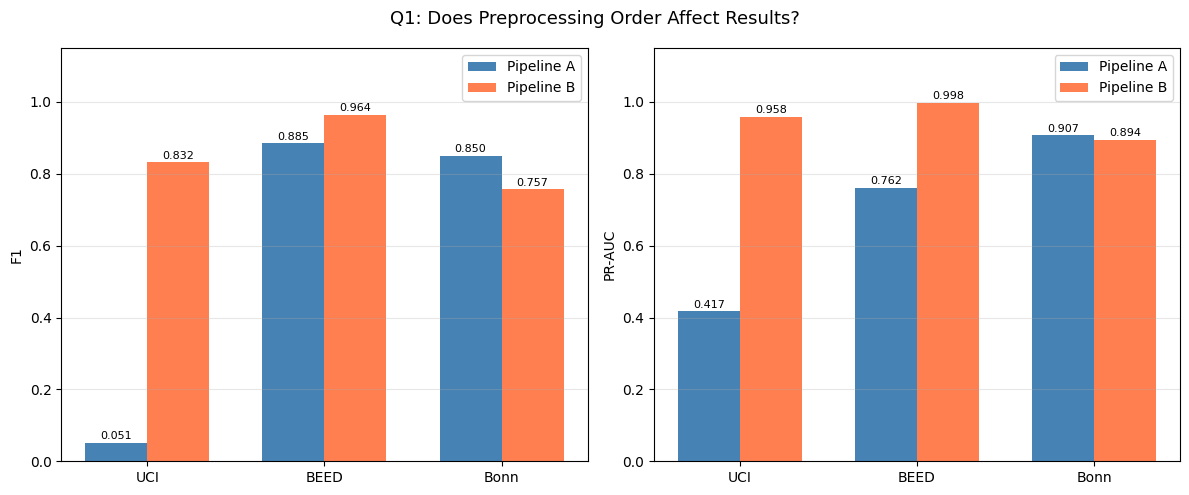

Dataset Pipeline     F1  PR-AUC
    UCI        A 0.0508  0.4171
    UCI        B 0.8315  0.9580
   BEED        A 0.8850  0.7618
   BEED        B 0.9642  0.9982
   Bonn        A 0.8500  0.9069
   Bonn        B 0.7568  0.8942


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, average_precision_score

# Rebuild pipeline results cleanly for comparison
datasets_raw = {
    'UCI':  (X1_train, X1_test, y1_train, y1_test),
    'BEED': (X2_train, X2_test, y2_train, y2_test),
    'Bonn': (X3_train, X3_test, y3_train, y3_test),
}

def make_pipeline_A(n):
    return Pipeline([
        ('scaler',   StandardScaler()),
        ('noise',    VarianceThreshold(threshold=0.01)),
        ('selector', SelectKBest(f_classif, k=min(20, n)))
    ])

def make_pipeline_B():
    return Pipeline([
        ('extractor', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ('scaler',    MinMaxScaler()),
        ('pca',       PCA(n_components=20))
    ])

q1_records = []
for ds, (Xtr, Xte, ytr, yte) in datasets_raw.items():
    for pipe_name, pipe in [('A', make_pipeline_A(Xtr.shape[1])),
                             ('B', make_pipeline_B())]:
        Xtr_t = pipe.fit_transform(Xtr, ytr)
        Xte_t = pipe.transform(Xte)
        model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        model.fit(Xtr_t, ytr)
        f1    = f1_score(yte, model.predict(Xte_t), zero_division=0)
        prauc = average_precision_score(yte, model.predict_proba(Xte_t)[:,1])
        q1_records.append({'Dataset': ds, 'Pipeline': pipe_name,
                            'F1': round(f1,4), 'PR-AUC': round(prauc,4)})

df_q1 = pd.DataFrame(q1_records)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Q1: Does Preprocessing Order Affect Results?', fontsize=13)

for ax, metric in zip(axes, ['F1', 'PR-AUC']):
    x = np.arange(3)
    w = 0.35
    ds_names = ['UCI', 'BEED', 'Bonn']
    pA = df_q1[df_q1['Pipeline']=='A'][metric].values
    pB = df_q1[df_q1['Pipeline']=='B'][metric].values
    b1 = ax.bar(x - w/2, pA, w, label='Pipeline A', color='steelblue')
    b2 = ax.bar(x + w/2, pB, w, label='Pipeline B', color='coral')
    for b, v in zip(b1, pA): ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
    for b, v in zip(b2, pB): ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(ds_names)
    ax.set_ylabel(metric); ax.set_ylim(0, 1.15)
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q1_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_q1.to_string(index=False))

=== Stability (lower std = more stable across datasets) ===
             F1_std  PRAUC_std
Regularizer                   
Elastic Net  0.4180     0.2419
L1           0.4236     0.2460
L2           0.4135     0.2438

=== Full Results ===
Dataset Regularizer     F1  PR-AUC
    UCI          L1 0.1483  0.4323
    UCI          L2 0.1520  0.4312
    UCI Elastic Net 0.1446  0.4345
   BEED          L1 0.8859  0.7608
   BEED          L2 0.8850  0.7618
   BEED Elastic Net 0.8859  0.7613
   Bonn          L1 0.8780  0.9137
   Bonn          L2 0.8500  0.9069
   Bonn Elastic Net 0.8500  0.9069


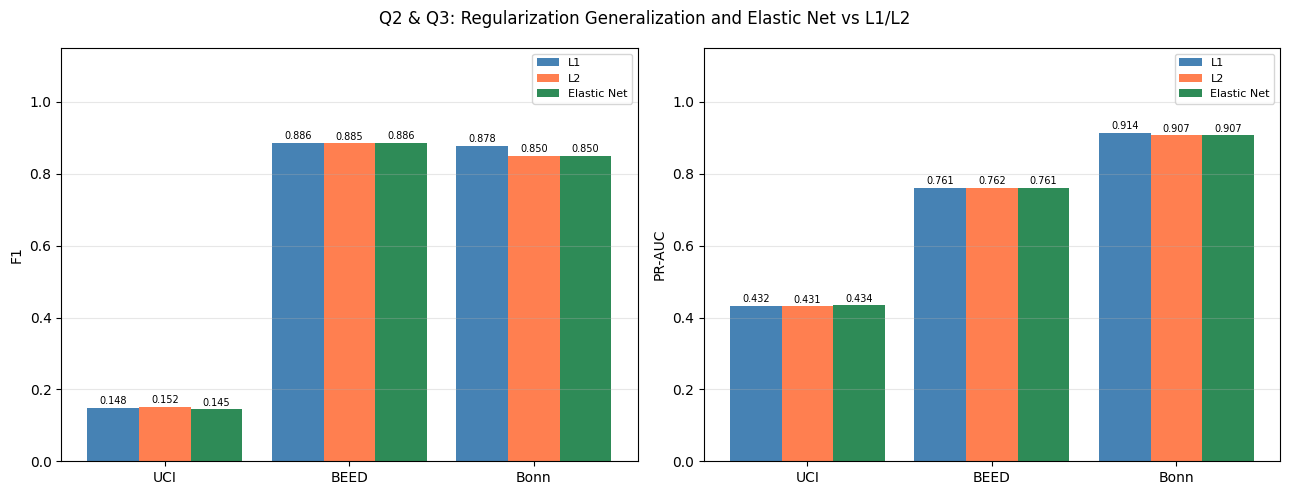

In [27]:
from sklearn.metrics import accuracy_score

reg_configs = {
    'L1':          dict(penalty='l1', solver='liblinear', C=1.0, max_iter=1000),
    'L2':          dict(penalty='l2', solver='lbfgs',     C=1.0, max_iter=1000),
    'Elastic Net': dict(penalty='elasticnet', solver='saga',
                        C=1.0, l1_ratio=0.5, max_iter=5000),
}

q2_records = []
for ds, (Xtr, Xte, ytr, yte) in datasets_raw.items():
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)
    for reg, params in reg_configs.items():
        model = LogisticRegression(random_state=42, **params)
        model.fit(Xtr_sc, ytr)
        f1    = f1_score(yte, model.predict(Xte_sc), zero_division=0)
        prauc = average_precision_score(yte, model.predict_proba(Xte_sc)[:,1])
        q2_records.append({'Dataset': ds, 'Regularizer': reg,
                           'F1': round(f1,4), 'PR-AUC': round(prauc,4)})

df_q2 = pd.DataFrame(q2_records)

# Stability: std across datasets per regularizer
stability = df_q2.groupby('Regularizer')[['F1','PR-AUC']].std().round(4)
stability.columns = ['F1_std', 'PRAUC_std']
print("=== Stability (lower std = more stable across datasets) ===")
print(stability)
print("\n=== Full Results ===")
print(df_q2.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q2 & Q3: Regularization Generalization and Elastic Net vs L1/L2', fontsize=12)

colors = {'L1': 'steelblue', 'L2': 'coral', 'Elastic Net': 'seagreen'}
ds_names = ['UCI', 'BEED', 'Bonn']
x = np.arange(3)
w = 0.28

for ax, metric in zip(axes, ['F1', 'PR-AUC']):
    for i, (reg, color) in enumerate(colors.items()):
        vals = df_q2[df_q2['Regularizer']==reg][metric].values
        bars = ax.bar(x + (i-1)*w, vals, w, label=reg, color=color)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(ds_names)
    ax.set_ylabel(metric); ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q2_q3_regularization.png', dpi=150, bbox_inches='tight')
plt.show()

=== Q4: Imbalance × Regularization Interaction (UCI) ===
      Technique Regularizer  Precision  Recall     F1  PR-AUC
    No Handling          L1     0.9487  0.0804 0.1483  0.4323
    No Handling          L2     0.9500  0.0826 0.1520  0.4312
    No Handling Elastic Net     0.9474  0.0783 0.1446  0.4345
          SMOTE          L1     0.3137  0.4283 0.3621  0.4140
          SMOTE          L2     0.3146  0.4370 0.3658  0.4135
          SMOTE Elastic Net     0.3144  0.4326 0.3641  0.4164
  Undersampling          L1     0.2866  0.4087 0.3369  0.4087
  Undersampling          L2     0.2873  0.4022 0.3351  0.3924
  Undersampling Elastic Net     0.2910  0.4087 0.3400  0.4044
Class Weighting          L1     0.3179  0.4022 0.3551  0.4015
Class Weighting          L2     0.3137  0.3935 0.3491  0.3979
Class Weighting Elastic Net     0.3160  0.3957 0.3514  0.4019


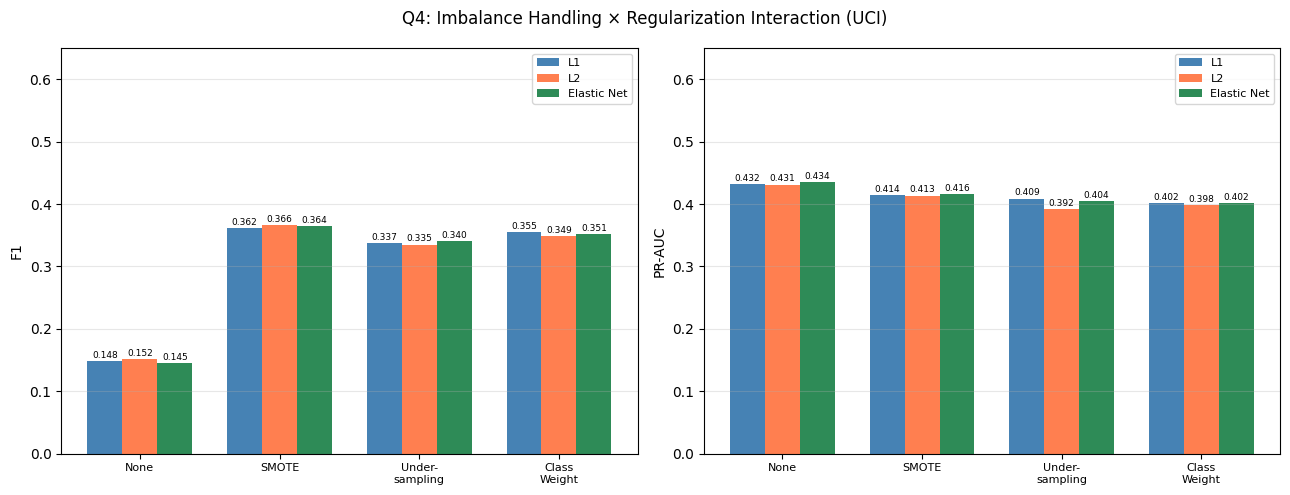

In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_score, recall_score

imbalance_techniques = {
    'No Handling':     None,
    'SMOTE':           SMOTE(random_state=42),
    'Undersampling':   RandomUnderSampler(random_state=42),
    'Class Weighting': 'balanced',
}

q4_records = []
# Use UCI only (most pronounced imbalance)
Xtr, Xte, ytr, yte = datasets_raw['UCI']
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr)
Xte_sc = sc.transform(Xte)

for tech_name, sampler in imbalance_techniques.items():
    if sampler is None or sampler == 'balanced':
        X_res, y_res = Xtr_sc, ytr
    else:
        X_res, y_res = sampler.fit_resample(Xtr_sc, ytr)

    for reg, params in reg_configs.items():
        p = dict(params)
        if sampler == 'balanced':
            p['class_weight'] = 'balanced'
        model = LogisticRegression(random_state=42, **p)
        model.fit(X_res, y_res)
        prec  = precision_score(yte, model.predict(Xte_sc), zero_division=0)
        rec   = recall_score(yte, model.predict(Xte_sc), zero_division=0)
        f1    = f1_score(yte, model.predict(Xte_sc), zero_division=0)
        prauc = average_precision_score(yte, model.predict_proba(Xte_sc)[:,1])
        q4_records.append({
            'Technique': tech_name, 'Regularizer': reg,
            'Precision': round(prec,4), 'Recall': round(rec,4),
            'F1': round(f1,4), 'PR-AUC': round(prauc,4)
        })

df_q4 = pd.DataFrame(q4_records)
print("=== Q4: Imbalance × Regularization Interaction (UCI) ===")
print(df_q4.to_string(index=False))

# Heatmap-style plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q4: Imbalance Handling × Regularization Interaction (UCI)', fontsize=12)

techs = ['No Handling', 'SMOTE', 'Undersampling', 'Class Weighting']
regs  = ['L1', 'L2', 'Elastic Net']
x = np.arange(len(techs))
w = 0.25

for ax, metric in zip(axes, ['F1', 'PR-AUC']):
    for i, (reg, color) in enumerate(colors.items()):
        vals = [df_q4[(df_q4['Technique']==t) &
                      (df_q4['Regularizer']==reg)][metric].values[0] for t in techs]
        bars = ax.bar(x + (i-1)*w, vals, w, label=reg, color=color)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['None', 'SMOTE', 'Under-\nsampling', 'Class\nWeight'], fontsize=8)
    ax.set_ylabel(metric); ax.set_ylim(0, 0.65)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q4_interaction.png', dpi=150, bbox_inches='tight')
plt.show()